# Supplementary Material:
# Thermodynamic consistency tests for Isobaric Vapor-Liquid Equilibria of Dibutyl Ether + Butan-1-ol Binary Mixture.

*Juan M. Uceda, Marcela Cartes and Andrés Mejía*

This notebook is used for the point-point consistency test based on the $\gamma - \phi$ Fredenslund et al., approach. The vapor phase is modeled using the truncated virial equation of state, where the second virial coefficients are calculated following Hayden-O'Connell's method. The liquid phase is modeled by the activity coefficient which is calculated from the modified Raoult law. 
This notebook uses an external Excel file (dbe-1butanol.xlsx) which contains the experimental data and the Phasepy suite, which is free download at https://pypi.python.org/pypi/phasepy/

For further details and thermodynamical properties of pure fluids, the reader is redirected to “Measurements and Theoretical Modeling of Isobaric Vapor-Liquid Equilibria and Dynamic Viscosity for the Dibutyl Ether and Butan-1-ol Binary Mixture” by J. M. Uceda, M. Cartes and A. Mejía. Journal of Chemical & Engineering Data (2025)- Under Review



In [1]:
import numpy as np
from phasepy import component, mixture
from __future__ import division, print_function, absolute_import
from collections import Counter
from pandas import read_excel
import os
from copy import copy
from itertools import combinations

class component(object):
    '''
    Object class for storing pure component information.

    Parameters
    ----------
    name : str
        Name of the component
    Tc : float
        Critical temperature [K]
    Pc : float
        Critical pressure [bar]
    Zc : float
        Critical compressibility factor
    Vc : float
        Critical molar volume [:math:`\mathrm{cm^3/mol}`]
    w  : float
        Acentric factor
    mu : float
        Dipole moment
    Rg : float
        Mean radius of gyration [A]
    eta: float
        Association parameter in Hayden and O'Connell's method
    c : float
        Volume translation parameter used in cubic EoS [:math:`\mathrm{cm^3/mol}`]
    cii : List[float]
        Polynomial coefficients for influence parameter used in SGT model
    ksv : List[float]
        Parameter for alpha for PRSV EoS
    Ant : List[float]
        Antoine correlation parameters
    a: float
        Parameter a in Tsonopoulos correlation
    b: float
        Parameter b in Tsonopoulos correlation
    GC : dict
        Group contribution information used in Modified-UNIFAC
        activity coefficient model. Group definitions can be found `here
        <http://www.ddbst.com/PublishedParametersUNIFACDO.html#ListOfMainGroups>`_.
    Mw : float
        molar weight of the fluid [g/mol]
    ri : float
        Component molecular volume for UNIQUAC model
    qi : float
        Component molecular surface for UNIQUAC model
    '''

    def __init__(self, name='None', Tc=0, Pc=0, Zc=0, Vc=0, w=0, mupol=0, Rg=0, eta=0, 
                 a=0, b=0, cii=0, ksv=[0, 0], c=0, Ant=[0, 0, 0], GC=None, Mw=1.,
                 ri=0., qi=0.):
        R=83.14
        self.name = name
        self.Tc = Tc  # Critical temperature in K
        self.Pc = Pc  # Critical pressure in bar
        self.Zc = Zc  # Critical compressibility factor
        self.Vc = Vc  # Critical volume in cm3/mol
        if Vc == 0 and Zc != 0:
            self.Vc = R*Zc*Tc/Pc
        elif Vc != 0 and Zc == 0:
            self.Zc = Pc*Vc/(R*Tc)
        self.w = w  # Acentric factor
        self.mupol = mupol  # Dipole moment in Debye
        self.Rg = Rg  # Mean radius of gyration in Angstrom
        self.eta = eta  # Association parameter in Hayden and O'Connell's method
        self.Ant = Ant  # Antoine coefficeint, base e = 2.71
        self.a = a  # a parameter in Tsonopoulos correlation
        self.b = b  # b parameter in Tsonopoulos correlation
        self.cii = cii  # Influence factor SGT, list or array
        self.ksv = ksv
        self.c = c  # volume translation for cubic EoS
        self.GC = GC  # Dict, Group contribution info
        self.nc = 1
        self.Mw = Mw  # Molar weight in g/mol
        self.ri = ri  # Component molecular volume for UNIQUAC model
        self.qi = qi  # Component molecular surface for UNIQUAC model


    def __add__(self, component2):
        '''
        Methods to add two components and create a mixture with them.
        '''
        return mixture(self, component2)

    def psat(self, T):
        """
        Returns vapor saturation pressure [bar] at a given temperature
        using Antoine equation. Exponential base is :math:`e`.

        The following Antoine's equation is used:

        :math:`\ln (P /bar) = A - \frac{B}{T/K + C}`

        Parameters
        ----------
        T : float
            Absolute temperature [K]
        """

        coef = self.Ant
        return np.exp(coef[0]-coef[1]/(T+coef[2]))

    def tsat(self, P):
        """
        Returns vapor saturation temperature [K] at a given pressure using
        Antoine equation. Exponential base is :math:`e`.

        The following Antoine's equation is used:

        :math:`\ln (P /bar) = A - \frac{B}{T/K + C}`

        Parameters
        ----------
        P : float
            Saturation pressure [bar]
        """

        coef = self.Ant
        T = - coef[2] + coef[1] / (coef[0] - np.log(P))

        return T

    def vlrackett(self, T):
        """
        Returns liquid molar volume [:math:`\mathrm{cm^3/mol}`] at a given
        temperature using the Rackett equation.

        :math:`v = v_c Z_c^{(1 - T_r)^{2/7}}`

        Parameters
        ----------
        T : float
            Absolute temperature [K]
        """

        Tr = T/self.Tc
        V = self.Vc*self.Zc**((1-Tr)**(2/7))
        return V

    def ci(self, T):
        """
        Returns value of SGT model influence parameter
        [:math:`\mathrm{J m^5 / mol}`] at a given temperature.

        Parameters
        ----------
        T : float
            absolute temperature [K]
        """

        return np.polyval(self.cii, T)

class mixture(object):
    '''
    Object class for info about a mixture.

    Parameters
    ----------
    component1 : component
        First mixture component object
    component2 : component
        Second mixture component object

    Attributes
    ----------
    name : List[str]
        Names of the components
    Tc : List[float]
        Critical temperatures [K]
    Pc : List[float]
        Critical pressures [bar]
    Zc : List[float]
        critical compressibility factors
    Vc : List[float]
        Critical molar volumes [:math:`\mathrm{cm^3/mol}`]
    w  : List[float]
        Acentric factors
    mupol  : List[float]
        Dipolar moments [D]
    Rg  : List[float]
        Mean radius of gyration [A]
    eta  : List[float]
        Association parameter
    c : List[float]
        Volume translation parameter used in cubic EoS [:math:`\mathrm{cm^3/mol}`]
    cii : List[list]
        Polynomial coefficients for influence parameter used in SGT model
    ksv : List[list]
        Parameters for alpha for PRSV EoS, if fitted
    Ant : List[list]
        Antoine correlation parameters
    GC : List[dict]
        Group contribution information used in Modified-UNIFAC
        activity coefficient model. Group definitions can be found `here
        <http://www.ddbst.com/PublishedParametersUNIFACDO.html#ListOfMainGroups>`_.
    Mw : list[dict]
        molar weights of the fluids in the mixture [g/mol]
    qi: list[dict]
        Component molecular surface used in UNIQUAC model
    ri: list[dict]
        Component molecular volume used in UNIQUAC model
    '''

    def __init__(self, component1, component2):
        self.names = [component1.name, component2.name]
        self.Tc = [component1.Tc, component2.Tc]
        self.Pc = [component1.Pc, component2.Pc]
        self.Zc = [component1.Zc, component2.Zc]
        self.w = [component1.w, component2.w]
        self.mupol = [component1.mupol, component2.mupol]
        self.Rg = [component1.Rg, component2.Rg]
        self.eta = [component1.eta, component2.eta]
        self.Ant = [component1.Ant, component2.Ant]
        self.a = [component1.a, component2.a]
        self.b = [component1.b, component2.b]
        self.Vc = [component1.Vc, component2.Vc]
        self.cii = [component1.cii, component2.cii]
        self.c = [component1.c, component2.c]
        self.ksv = [component1.ksv, component2.ksv]
        self.nc = 2
        self.GC = [component1.GC,  component2.GC]
        self.Mw = [component1.Mw,  component2.Mw]
        self.ri = [component1.ri, component2.ri]
        self.qi = [component1.qi, component2.qi]


    def add_component(self, component):
        """
        Adds a component to the mixture
        """
        self.names.append(component.name)
        self.Tc.append(component.Tc)
        self.Pc.append(component.Pc)
        self.Zc.append(component.Zc)
        self.Vc.append(component.Vc)
        self.w.append(component.w)
        self.mupol.append(component.mupol)
        self.Rg.append(component.Rg)
        self.eta.append(component.eta)
        self.Ant.append(component.Ant)
        self.a.append(component.a)
        self.b.append(component.b)
        self.cii.append(component.cii)
        self.c.append(component.c)
        self.ksv.append(component.ksv)
        self.GC.append(component.GC)
        self.Mw.append(component.Mw)
        self.ri.append(component.ri)
        self.qi.append(component.qi)

        self.nc += 1

    def __add__(self, new_component):
        if isinstance(new_component, component):
            self.add_component(new_component)
        else:
            raise Exception('You can only add components objects to an existing mixture')
        return self

    def psat(self, T):
        """
        Returns array of vapour saturation pressures [bar] at a given
        temperature using Antoine equation. Exponential base is :math:`e`.

        The following Antoine's equation is used:

        :math:`\ln (P /bar) = A - \frac{B}{T/K + C}`

        Parameters
        ----------
        T : float
            Absolute temperature [K]

        Returns
        -------
        Psat : array_like
            saturation pressure of each component [bar]
        """

        coef = np.vstack(self.Ant)
        return np.exp(coef[:, 0]-coef[:, 1]/(T+coef[:, 2]))

    def tsat(self, P):
        """
        Returns array of vapour saturation temperatures [K] at a given pressure
        using Antoine equation. Exponential base is :math:`e`.

        The following Antoine's equation is used:

        :math:`\ln (P /bar) = A - \frac{B}{T/K + C}`

        Parameters
        ----------
        Psat : float
            Saturation pressure [bar]

        Returns
        -------
        Tsat : array_like
            saturation temperature of each component [K]
        """

        coef = np.vstack(self.Ant)
        T = - coef[:, 2] + coef[:, 1] / (coef[:, 0] - np.log(P))
        return T

    def vlrackett(self, T):
        """
        Returns array of liquid molar volumes [:math:`\mathrm{cm^3/mol}`] at a
        given temperature using the Rackett equation.

        :math:`v = v_c Z_c^{(1 - T_r)^{2/7}}`

        Parameters
        ----------
        T : float
            Absolute temperature [K]

        Returns
        -------
        vl : array_like
            liquid volume of each component [cm3 mol-1]
        """

        Tc = np.array(self.Tc)
        Vc = np.array(self.Vc)
        Zc = np.array(self.Zc)
        Tr = T/Tc
        V = Vc*Zc**((1-Tr)**(2/7))
        return V

   
    def copy(self):
        """
        Returns a copy of the mixture object
        """
        return copy(self)

In [2]:
#define components
import math
DBE = component(name='DBE', Tc=584.1, Pc=24.6, Zc=0.247, Ant=[(8.54371*math.log(10)-math.log(100)), 3329.5600*math.log(10), 95.97533], Rg=4.797, mupol=1.17, Mw=130.23)
nbOH = component(name='nbOH', Tc=563.0, Pc=44.14, Zc=0.258, Ant=[(6.4552*math.log(10)-math.log(100)), 1285.522*math.log(10), -101.6256], a=0.0878, Rg=3.225, mupol=1.66, Mw=74.12)

In [3]:
#calculate acentric factors
def acentric(component):
    """
    calculate the acentric factor by definition:
    
    w = -log10(psat(Tr=0.7)/Pc)-1

    Parameters
    ----------
    Pc: Critical pressure in bar
    Tc: Critical temperature in K
    A, B, C: Antoine parameters

    Returns
    -------
    w: acentric factor
    """
    import math
    T = component.Tc*0.7
    p = component.psat(T)
    w = -math.log10(p/component.Pc)-1
    return w

In [4]:
w1 = acentric(DBE)
w2 = acentric(nbOH)
print(w1)
print(w2)

0.4424331879625196
0.5849640228132138


In [5]:
import math
DBE = component(name='DBE', Tc=584.1, Pc=24.6, Zc=0.247, Ant=[(8.54371*math.log(10)-math.log(100)), 3329.5600*math.log(10), 95.97533], Rg=4.797, mupol=1.17, Mw=130.23)
nbOH = component(name='nbOH', Tc=563.0, Pc=44.14, Zc=0.258, Ant=[(6.4552*math.log(10)-math.log(100)), 1285.522*math.log(10), -101.6256], a=0.0878, Rg=3.225, mupol=1.66, Mw=74.12)

In [6]:
nbOH.Vc

273.5935106479384

In [7]:
#read experimental VLE data
import pandas as pd
dfVLE50 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_50')
dfVLE75 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_75')
dfVLE94 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_94')
#50.00 kPa
Texp50 = dfVLE50['T/K'].to_numpy()
pexp50 = dfVLE50['p/kPa'].to_numpy()
x1exp50 = dfVLE50['x1'].to_numpy()
y1exp50 = dfVLE50['y1'].to_numpy()
#75.00 kPa
Texp75 = dfVLE75['T/K'].to_numpy()
pexp75 = dfVLE75['p/kPa'].to_numpy()
x1exp75 = dfVLE75['x1'].to_numpy()
y1exp75 = dfVLE75['y1'].to_numpy()
#94.00 kPa
Texp94 = dfVLE94['T/K'].to_numpy()
pexp94 = dfVLE94['p/kPa'].to_numpy()
x1exp94 = dfVLE94['x1'].to_numpy()
y1exp94 = dfVLE94['y1'].to_numpy()

In [8]:
dfVLE50.head(n=24)

,T/K,p/kPa,x1,y1
0,371.907315,50,0.000,0.000
1,370.920000,50,0.102,0.120
2,370.380000,50,0.150,0.161
3,370.630000,50,0.197,0.195
4,369.920000,50,0.246,0.227
5,369.430000,50,0.294,0.256
6,369.660000,50,0.342,0.280
7,369.680000,50,0.392,0.305
8,369.840000,50,0.444,0.328
9,370.260000,50,0.497,0.355


In [9]:
dfVLE75.head(n=22)

,T/K,p/kPa,x1,y1
0,382.298757,75,0.000,0.000
1,381.050000,75,0.102,0.110
2,380.880000,75,0.150,0.148
3,380.760000,75,0.198,0.181
4,380.540000,75,0.248,0.212
5,380.210000,75,0.294,0.237
6,380.350000,75,0.343,0.261
7,380.460000,75,0.395,0.285
8,380.900000,75,0.445,0.309
9,381.310000,75,0.498,0.334


In [10]:
dfVLE94.head(n=23)

,T/K,p/kPa,x1,y1
0,388.439814,94,0.000,0.000
1,387.250000,94,0.102,0.105
2,387.100000,94,0.151,0.142
3,386.790000,94,0.198,0.174
4,386.520000,94,0.247,0.203
5,386.400000,94,0.295,0.229
6,386.500000,94,0.343,0.254
7,386.760000,94,0.394,0.277
8,387.210000,94,0.444,0.300
9,387.550000,94,0.495,0.325


In [11]:
#50.00 kPa
Xexp50 = np.array([x1exp50, 1-x1exp50])
Yexp50 = np.array([y1exp50, 1-y1exp50])
datavle50 = (Xexp50, Yexp50, Texp50, pexp50)
#75.00 kPa
Xexp75 = np.array([x1exp75, 1-x1exp75])
Yexp75 = np.array([y1exp75, 1-y1exp75])
datavle75 = (Xexp75, Yexp75, Texp75, pexp75)
#94.00 kPa
Xexp94 = np.array([x1exp94, 1-x1exp94])
Yexp94 = np.array([y1exp94, 1-y1exp94])
datavle94 = (Xexp94, Yexp94, Texp94, pexp94)

In [12]:
#read experimental data on second virial coefficients
#n-butanol (2)
virial = pd.read_excel('dbe-1butanol.xlsx', sheet_name='virial')

Texp = virial['T/C'].to_numpy()+273.2
Bexp = virial['B/cm3 mol-1'].to_numpy()
uexp = virial['u/cm3 mol-1'].to_numpy()

virial.head(n=5)

,T/C,B/cm3 mol-1,u/cm3 mol-1
0,120,-1053,16
1,135,-903,7
2,150,-773,13
3,166,-624,9


In [13]:
def Hayden_obj(E, component, Texp, Bexp):
    
    wm = 0.006*component.Rg+0.02087*component.Rg**2-0.00136*component.Rg**3
    ek0 = component.Tc*(0.748+0.91*wm-0.4*E[0]/(2+20*wm))
    sigma03 = (2.44-wm)**3*component.Tc/(component.Pc/1.013)
    if component.mupol < 1.45:
        mur = 7243.8*component.mupol**2/ek0/sigma03
        A = -0.3-0.05*mur
        dH = 1.99+0.2*mur**2
        b0 = 1.2618*sigma03
        Bmb = b0*A*np.exp(dH/Texp*ek0)
        invTr = ek0/Texp-1.6*wm
        Bnp = b0*(0.94-1.47*invTr-0.85*invTr**2+1.015*invTr**3)
        Bp = 0
        Bc = 0
    else:
        C = 2.882-1.882*wm/(0.03+wm)
        xi = component.mupol**4/(5.723e-08*C*ek0*sigma03**2*component.Tc)
        n = 16+400*wm
        ek = ek0/(1+xi)**(n/(n-6))
        sigma3 = sigma03*(1+xi)**(3/(n-6))
        mur = 7243.8*component.mupol**2/ek/sigma3
        if mur >= 0.25:
            murr = mur-0.25
        elif mur >= 0.04:
            murr = 0
        else:
            murr = mur
        A = -0.3-0.05*mur
        dH = 1.99+0.2*mur**2
        b0 = 1.2618*sigma3
        Bmb = b0*A*np.exp(dH/Texp*ek)
        invTr = ek/Texp-1.6*wm
        Bnp = b0*(0.94-1.47*invTr-0.85*invTr**2+1.015*invTr**3)
        Bp = -b0*murr*(0.75-3*invTr+2.1*invTr**2+2.1*invTr**3)
        Bc = b0*np.exp(E[0]*(650/(ek+300)-4.27))*(1-np.exp(1500*E[0]/Texp))

    Bf = Bnp+Bp
    B = Bf+Bmb+Bc
    
    N = len(Bexp)
    SDHay = np.sqrt(np.sum((B-Bexp)**2)/(N-1))
    
    return SDHay

def fit_Hayden(component, Texp, Bexp, e0=[0]):
    fit = minimize(Hayden_obj, e0, args=(component, Texp, Bexp))
    return fit

def Hayden(mix, T, matrix_eta):
    
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    Rg = np.asarray(mix.Rg)
    mupol = np.asarray(mix.mupol)
    eta = np.asarray(mix.eta)
    c = len(mupol)
    wm = np.zeros(c)
    ek0 = np.zeros(c)
    ek = np.zeros(c)
    sigma03 = np.zeros(c)
    sigma3 = np.zeros(c)
    mupolr = np.zeros(c)
    mupolrr = np.zeros(c)
    for i in range(c):
        wm[i] = 0.006*Rg[i]+0.02087*Rg[i]**2-0.00136*Rg[i]**3
        ek0[i] = Tc[i]*(0.748+0.91*wm[i]-0.4*eta[i]/(2+20*wm[i]))
        sigma03[i] = (2.44-wm[i])**3*Tc[i]/(Pc[i]/1.013)
        if mupol[i] < 1.45:
            ek[i] = ek0[i]
            sigma3[i] = sigma03[i]
            
        else:
            C = 2.882-1.882*wm[i]/(0.03+wm[i])
            xi = mupol[i]**4/(5.723e-08*C*ek0[i]*sigma03[i]**2*Tc[i])
            n = 16+400*wm[i]
            ek[i] = ek0[i]/(1+xi)**(n/(n-6))
            sigma3[i] = sigma03[i]*(1+xi)**(3/(n-6))
    
    wmij = np.add.outer(wm, wm)/2   
    ekij = 0.7*np.sqrt(np.outer(ek, ek))+0.6/(np.add.outer(1/ek, 1/ek))
    sigma3ij = np.sqrt(np.outer(sigma3, sigma3))
    mupolrij = 7243.8*np.outer(mupol, mupol)/ekij/sigma3ij
    mupolrrij = np.zeros_like(mupolrij)
    for i in range(c):
        for j in range(c):
            if mupol[i] > 1.45:
                if mupolrij[i,j] >= 0.25:
                    mupolrrij[i,j] = mupolrij[i,j]-0.25
                elif mupolrij[i,j] >= 0.04:
                    mupolrrij[i,j] = 0
                else:
                    mupolrrij[i,j] = mupolrij[i,j]
            else:
                mupolrrij[i,j] = 0
            
    A = -0.3-0.05*mupolrij
    dH = 1.99+0.2*mupolrij**2
    b0 = 1.2618*sigma3ij
    invTrij = ekij/T-1.6*wmij
    Bnpij = b0*(0.94-1.47*invTrij-0.85*invTrij**2+1.015*invTrij**3)
    Bpij = -b0*mupolrrij*(0.75-3*invTrij+2.1*invTrij**2+2.1*invTrij**3)
    Bmbij = b0*A*np.exp(dH/T*ekij)
    Bcij = b0*np.exp(matrix_eta*(650/(ek+300)-4.27))*(1-np.exp(1500*matrix_eta/T))
    Bij = Bnpij+Bpij+Bmbij+Bcij
    
    return Bij

def atson(component, group):
    '''
    calculate Tsonopoulos' "a" parameter according to an empirical correlation given for a specific functional group.
    Parameters
    ----------------------------------
    component
    group: functional group (ketone, aldehyde, alkyl_nitrile, ether, ester, alkyl_halide, mercaptan, sulfide, disulfide)
    
    '''
    mupolr = 0.9869e05*component.mupol**2*component.Pc/component.Tc**2
    if group=='ketone' or group=='aldehyde' or group=='alkyl_nitrile' or group=='ether' or group=='ester':
        a = -2.14e-04*mupolr-4.308e-21*mupolr**8
    elif group=='alkyl_halide' or group=='mercaptan' or group=='sulfide' or group=='disulfide':
        a = -2.188e-11*mupolr**4-7.831e-21*mupolr**8
    else:
        print('No correlation for a')
    return a

def Tsonopoulos_obj(V, component, Texp, Bexp, uexp):
    
    Tr = Texp/component.Tc
    f0 = 0.1445-0.330/Tr-0.1385/Tr**2-0.0121/Tr**3-0.000607/Tr**8
    f1 = 0.0637+0.331/Tr**2-0.423/Tr**3-0.008/Tr**8
    f2 = 1/Tr**6
    f3 = -1/Tr**8
    p = 1/uexp**2
    
    B = 83.14*component.Tc/component.Pc*(f0+component.w*f1+component.a*f2+V[0]*f3)
    RMS = np.sqrt(np.sum(p*(B-Bexp)**2)/np.sum(p))
    
    return RMS

def fit_Tsonopoulos(component, Texp, Bexp, uexp, v0=[0]):
    fit = minimize(Tsonopoulos_obj, v0, args=(component, Texp, Bexp, uexp))
    return fit

def Tsonopoulos(mix, T, kij):
    
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    w = np.asarray(mix.w)
    a = np.asarray(mix.a)
    b = np.asarray(mix.b)
    u = Pc*Vc/Tc
    
    Vc3 = Vc**(1/3)
    Tcij = np.sqrt(np.outer(Tc, Tc))*(1-kij)
    Pcij = 4*Tcij*(np.add.outer(u, u))/(np.add.outer(Vc3, Vc3))**3
    wij = np.add.outer(w, w)/2
    aij = np.add.outer(a, a)/2
    bij = np.add.outer(b, b)/2 
    Tr = T/Tcij
    f0 = 0.1445-0.330/Tr-0.1385/Tr**2-0.0121/Tr**3-0.000607/Tr**8
    f1 = 0.0637+0.331/Tr**2-0.423/Tr**3-0.008/Tr**8
    f2 = 1/Tr**6
    f3 = -1/Tr**8
    Bij = 83.14*Tcij/Pcij*(f0+wij*f1+aij*f2+bij*f3)
    
    return Bij

In [14]:
aTsoDBE = atson(DBE, 'ether')
print(aTsoDBE)

-0.0020845837141580835


In [15]:
from scipy.optimize import minimize
opt_eta=fit_Hayden(nbOH, Texp, Bexp, e0=[2.2])
print(opt_eta)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 22.881057744399353
        x: [ 2.218e+00]
      nit: 4
      jac: [-3.099e-06]
 hess_inv: [[ 2.441e-03]]
     nfev: 12
     njev: 6


In [16]:
from scipy.optimize import minimize
opt_b2=fit_Tsonopoulos(nbOH, Texp, Bexp, uexp, v0=[0.0367])
print(opt_b2)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 18.817342053393837
        x: [ 6.349e-02]
      nit: 6
      jac: [ 5.007e-06]
 hess_inv: [[ 1.199e-07]]
     nfev: 20
     njev: 10


In [17]:
#define pure components
DBE = component(name='DBE', Tc=584.1, Pc=24.6, Zc=0.247, w=w1, Ant=[(8.54371*math.log(10)-math.log(100)), 3329.5600*math.log(10), 95.97533], a=aTsoDBE, b=0, Rg=4.797, eta=0, mupol=1.17, Mw=130.23)
nbOH = component(name='nbOH', Tc=563.0, Pc=44.14, Zc=0.258, w=w2, Ant=[(6.4552*math.log(10)-math.log(100)), 1285.522*math.log(10), -101.6256], a=0.0878, b=opt_b2.x[0], Rg=3.225, eta=opt_eta.x[0], mupol=1.66, Mw=74.12)
mix = mixture(DBE, nbOH)

In [19]:
kij = np.array([[0, 0],
              [0, 0]])
etaij = np.array([[DBE.eta, 0],
                  [0, nbOH.eta]])

In [20]:
rangeT = np.linspace(300, 600)
n = len(rangeT)
B1Tso = np.zeros(n)
B12Tso = np.zeros(n)
B21Tso = np.zeros(n)
B2Tso = np.zeros(n)
B1Hay = np.zeros(n)
B12Hay = np.zeros(n)
B21Hay = np.zeros(n)
B2Hay = np.zeros(n)
B2Dym = np.zeros(n)
for i in range(n):
    [B1Tso[i], B12Tso[i]],[B21Tso[i], B2Tso[i]] = Tsonopoulos(mix, rangeT[i], kij)
    [B1Hay[i], B12Hay[i]],[B21Hay[i], B2Hay[i]] = Hayden(mix, rangeT[i], etaij)
    B2Dym[i] = 1.2021e02-1.5890e06/rangeT[i]+1.3878e09/rangeT[i]**2-3.6783e11/rangeT[i]**3

TexpFox = np.array([350.00, 371.00, 380.00])
B2expFox = np.array(([-1670, -1500, -1220]))
TexpSha = np.array([473.15, 498.15, 523.15, 548.15, 573.15])
B2expSha = np.array(([-511, -453, -417, -391, -382]))
TexpChe = np.array([338.15])
B1expChe =  np.array([-2650])

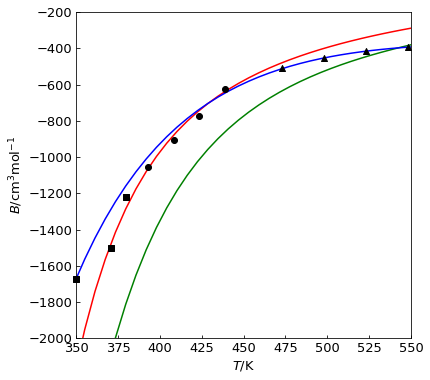

In [23]:
from matplotlib import rc
import matplotlib.pylab as plt
plt.rc('text', usetex=False)
fig = plt.figure(figsize = (6, 6))
plt.tick_params(direction='in')
plt.scatter(Texp, Bexp, c='black', clip_on=False, zorder=10)
plt.scatter(TexpFox, B2expFox, marker='s', c='black', clip_on=False, zorder=10)
plt.scatter(TexpSha, B2expSha, marker='^', c='black', clip_on=False, zorder=10)
plt.plot(rangeT, B2Tso, linestyle='solid', color='green')
plt.plot(rangeT, B2Hay, linestyle='solid', color='red')
plt.plot(rangeT, B2Dym, linestyle='solid', color='blue')
plt.xlabel(r'$\it{T}/\mathrm{K}$', fontsize=13)
plt.ylabel(r'$\it{B}/\mathrm{cm^{3} mol^{-1}}$', fontsize=13)
plt.xlim([350, 550])
plt.ylim([-2000, -200])
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig('virial_nbuOH.svg', format='svg', dpi=1200)

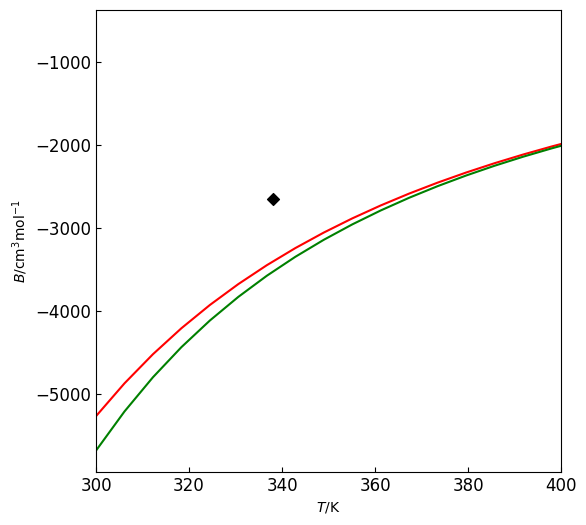

In [21]:
from matplotlib import rc
import matplotlib.pylab as plt
fig = plt.figure(figsize = (6, 6))
plt.tick_params(direction='in')
plt.scatter(TexpChe, B1expChe, marker='D', c='black', clip_on=False, zorder=10)
plt.plot(rangeT, B1Hay, linestyle='solid', color='red')
plt.plot(rangeT, B1Tso, linestyle='solid', color='green')
plt.xlabel(r'$\it{T}/\mathrm{K}$')
plt.ylabel(r'$\it{B}/\mathrm{cm^{3} mol^{-1}}$')
plt.xlim([300, 400])
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig('virial_DBE.svg', format='svg', dpi=1200)

In [22]:
def gamIdeal(mix, Texp, pexp, Xexp, Yexp):
    
    n = len(Texp)
    psat1 = np.zeros_like(Texp)
    psat2 = np.zeros_like(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    gExx = np.zeros_like(Texp)
    for i in range(n):
        psat1[i], psat2[i] = mix.psat(Texp[i])
        gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1[i]
        gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2[i]
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
        gExx[i] = gE[i]/Xexp[0,i]/Xexp[1,i]
    
    return gamma1, gamma2, gE, gExx

def gamTsonopoulos(mix, Texp, pexp, Xexp, Yexp, kij):
    
    n = len(Texp)
    psat1 = np.zeros_like(Texp)
    psat2 = np.zeros_like(Texp)
    vlsat1 = np.zeros_like(Texp)
    vlsat2 = np.zeros_like(Texp)
    B11 = np.zeros_like(Texp)
    B12 = np.zeros_like(Texp)
    B21 = np.zeros_like(Texp)
    B22 = np.zeros_like(Texp)
    d12 = np.zeros_like(Texp)
    d21 = np.zeros_like(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    gExx = np.zeros_like(Texp)
    for i in range(n):
        psat1[i], psat2[i] = mix.psat(Texp[i])
        vlsat1[i], vlsat2[i] = mix.vlrackett(Texp[i])
        [B11[i], B12[i]],[B21[i], B22[i]] = Tsonopoulos(mix, Texp[i], kij)
        d12[i] = 2*B12[i]-B22[i]-B11[i]
        d21[i] = 2*B21[i]-B11[i]-B22[i]
        gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1[i]*np.exp((B11[i]-vlsat1[i])*(pexp[i]-psat1[i])/83.14/Texp[i]+Yexp[1,i]**2*pexp[i]/83.14/Texp[i]*d12[i])
        gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2[i]*np.exp((B22[i]-vlsat2[i])*(pexp[i]-psat2[i])/83.14/Texp[i]+Yexp[0,i]**2*pexp[i]/83.14/Texp[i]*d21[i])
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
        gExx[i] = gE[i]/Xexp[0,i]/Xexp[1,i]
    
    return gamma1, gamma2, gE, gExx

def gamHayden(mix, Texp, pexp, Xexp, Yexp, etaij):
    
    n = len(Texp)
    psat1 = np.zeros_like(Texp)
    psat2 = np.zeros_like(Texp)
    vlsat1 = np.zeros_like(Texp)
    vlsat2 = np.zeros_like(Texp)
    B11 = np.zeros_like(Texp)
    B12 = np.zeros_like(Texp)
    B21 = np.zeros_like(Texp)
    B22 = np.zeros_like(Texp)
    d12 = np.zeros_like(Texp)
    d21 = np.zeros_like(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    gExx = np.zeros_like(Texp)
    for i in range(n):
        psat1[i], psat2[i] = mix.psat(Texp[i])
        vlsat1[i], vlsat2[i] = mix.vlrackett(Texp[i])
        [B11[i], B12[i]],[B21[i], B22[i]] = Hayden(mix, Texp[i], etaij)
        d12[i] = 2*B12[i]-B22[i]-B11[i]
        d21[i] = 2*B21[i]-B11[i]-B22[i]
        gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1[i]*np.exp((B11[i]-vlsat1[i])*(pexp[i]-psat1[i])/83.14/Texp[i]+Yexp[1,i]**2*pexp[i]/83.14/Texp[i]*d12[i])
        gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2[i]*np.exp((B22[i]-vlsat2[i])*(pexp[i]-psat2[i])/83.14/Texp[i]+Yexp[0,i]**2*pexp[i]/83.14/Texp[i]*d21[i])
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
        gExx[i] = gE[i]/Xexp[0,i]/Xexp[1,i]
    
    return gamma1, gamma2, gE, gExx

In [24]:
solIdeal50 = gamIdeal(mix, Texp50, pexp50/100, Xexp50, Yexp50)
solHayden50 = gamHayden(mix, Texp50, pexp50/100, Xexp50, Yexp50, etaij)
solIdeal75 = gamIdeal(mix, Texp75, pexp75/100, Xexp75, Yexp75)
solHayden75 = gamHayden(mix, Texp75, pexp75/100, Xexp75, Yexp75, etaij)
solIdeal94 = gamIdeal(mix, Texp94, pexp94/100, Xexp94, Yexp94)
solHayden94 = gamHayden(mix, Texp94, pexp94/100, Xexp94, Yexp94, etaij)

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/911009815.py:12: RuntimeWarning: invalid value encountered in scalar divide
  gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1[i]
/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/911009815.py:13: RuntimeWarning: invalid value encountered in scalar divide
  gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2[i]
/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/911009815.py:72: RuntimeWarning: invalid value encountered in scalar divide
  gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1[i]*np.exp((B11[i]-vlsat1[i])*(pexp[i]-psat1[i])/83.14/Texp[i]+Yexp[1,i]**2*pexp[i]/83.14/Texp[i]*d12[i])
/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/911009815.py:73: RuntimeWarning: invalid value encountered in scalar divide
  gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2[i]*np.exp((B22[i]-vlsat2[i])*(pexp[i]-psat2[i])/83.14/Texp[i]+Yexp[0,i]**2*pexp[i]/83.14/Texp[i]*d21[i])


In [25]:
from sympy import symbols
import sympy as sp
x = symbols('x')
c0 = symbols('c0') 
c1 = symbols('c1')
c2 = symbols('c2')
c3 = symbols('c3')
c4 = symbols('c4')
    
def Leg(n):
    '''
    Legendre's polynomials (from order 0 to 4)
    '''
    if n==0:
        return 1
    elif n==1:
        return 2*x-1
    elif n==2:
        return 6*(x**2-x+1/6)
    elif n==3:
        return 20*(x**3-3/2*x**2+3/5*x-1/20)
    elif n==4:
        return 70*(x**4-2*x**3+9/7*x**2-2/7*x+1/70)
    else:
        return 0
    
def excGibbs(n):
    if n==0:
        return x*(1-x)*c0*Leg(0)
    elif n==1:
        return x*(1-x)*(c0*Leg(0)+c1*Leg(1))
    elif n==2:
        return x*(1-x)*(c0*Leg(0)+c1*Leg(1)+c2*Leg(2))
    elif n==3:
        return x*(1-x)*(c0*Leg(0)+c1*Leg(1)+c2*Leg(2)+c3*Leg(3))
    elif n==4:
        return x*(1-x)*(c0*Leg(0)+c1*Leg(1)+c2*Leg(2)+c3*Leg(3)+c4*Leg(4))
    else:
        return 0
    
def diff_excGibbs(n):
    dgE = sp.diff(excGibbs(n), x)
    return dgE

def Leg_obj(L, N, mixture, mixij, Texp, pexp, Xexp, Yexp):
    R = 83.14
    s = len(Texp)
    psat1 = np.zeros(s)
    psat2 = np.zeros(s)
    vlsat1 = np.zeros(s)
    vlsat2 = np.zeros(s)
    B11 = np.zeros(s)
    B22 = np.zeros(s)
    B12 = np.zeros(s)
    B21 = np.zeros(s)
    d12 = np.zeros(s)
    d21 = np.zeros(s)
    Bp1 = np.zeros(s)
    Bp2 = np.zeros(s)
    gamma1 = np.zeros(s)
    gamma2 = np.zeros(s)
    phi1 = np.zeros(s)
    phi2 = np.zeros(s)
    phisat1 = np.zeros(s)
    phisat2 = np.zeros(s)
    zeta1 = np.zeros(s)
    zeta2 = np.zeros(s)
    F1 = np.zeros(s)
    F2 = np.zeros(s)
    p = np.zeros(s)
    y1 = np.zeros(s)
    for i in range(s):
        psat1[i], psat2[i] = mixture.psat(Texp[i])
        vlsat1[i], vlsat2[i] = mixture.vlrackett(Texp[i])
        [B11[i], B12[i]],[B21[i], B22[i]] = Hayden(mix, Texp[i], mixij)
        d12[i] = 2*B12[i]-B11[i]-B22[i]
        d21[i] = 2*B21[i]-B11[i]-B22[i]
        
        p0 = pexp[i]
        y10 = Yexp[0,i]
        
        gExc = excGibbs(N).evalf(subs={x: Xexp[0,i], c0: L[0], c1: L[1], c2: L[2], c3: L[3], c4: L[4]})
        dgExc = diff_excGibbs(N).evalf(subs={x: Xexp[0,i], c0: L[0], c1: L[1], c2: L[2], c3: L[3], c4: L[4]})
        gamma1[i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
        gamma2[i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
        Bp1[i] = B11[i]+(1-y10)**2*d12[i]
        Bp2[i] = B22[i]+y10**2*d21[i]
        phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
        phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
        phisat1[i] = np.exp(B11[i]*psat1[i]/R/Texp[i])
        phisat2[i] = np.exp(B22[i]*psat2[i]/R/Texp[i])
        zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
        zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
        F1[i] = phi1[i]/phisat1[i]/zeta1[i]
        F2[i] = phi2[i]/phisat2[i]/zeta2[i]
        p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
        y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]
        while abs(100*p[i]-100*p0)>=1.0e-12 and abs(y1[i]-y10)>=1.0e-12:
            p0 = p[i]
            y10 = y1[i]
            Bp1[i] = B11[i]+(1-y10)**2*d12[i]
            Bp2[i] = B22[i]+y10**2*d21[i]
            phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
            phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
            zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
            zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
            F1[i] = phi1[i]/phisat1[i]/zeta1[i]
            F2[i] = phi2[i]/phisat2[i]/zeta2[i]
            p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
            y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]
        
    solHayden = gamHayden(mix, Texp[1:s-1], pexp[1:s-1], Xexp[:,1:s-1], Yexp[:,1:s-1], etaij)
        
    error = np.sum((p/pexp-1)**2+(y1-Yexp[0])**2)
    
    return error

def fit_Leg(N, mixture, mixij, Texp, pexp, Xexp, Yexp, l0=[0, 0, 0, 0, 0]):
    fit = minimize(Leg_obj, l0, args=(N, mixture, mixij, Texp, pexp, Xexp, Yexp), method='SLSQP')
    return fit

def bLeg_stats(N, params, mixture, mixij, Texp, pexp, Xexp, Yexp):
    R = 83.14
    s = len(Texp)
    p = np.zeros(s)
    y1 = np.zeros(s)
    for i in range(s):
        psat1, psat2 = mixture.psat(Texp[i])
        vlsat1, vlsat2 = mixture.vlrackett(Texp[i])
        [B11, B12],[B21, B22] = Hayden(mix, Texp[i], mixij)
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22

        p0 = pexp[i]
        y10 = Yexp[0,i]
        
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/R/Texp[i])
        phi2 = np.exp(Bp2*p0/R/Texp[i])
        phisat1 = np.exp(B11*psat1/R/Texp[i])
        phisat2 = np.exp(B22*psat2/R/Texp[i])
        zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
        zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        gExc = excGibbs(N).evalf(subs={x: Xexp[0,i], c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
        dgExc = diff_excGibbs(N).evalf(subs={x: Xexp[0,i], c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
        gamma1 = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
        gamma2 = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
        p[i] = Xexp[0,i]*gamma1*psat1/F1+Xexp[1,i]*gamma2*psat2/F2
        y1[i] = Xexp[0,i]*gamma1*psat1/F1/p[i]
        while abs(p[i]-p0)>=1.0e-08 and abs(y1[i]-y10)>=1.0e-08:
            p0 = p[i]
            y10 = y1[i]
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/R/Texp[i])
            phi2 = np.exp(Bp2*p0/R/Texp[i])
            zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
            zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            p[i] = Xexp[0,i]*gamma1*psat1/F1+Xexp[1,i]*gamma2*psat2/F2
            y1[i] = Xexp[0,i]*gamma1*psat1/F1/p[i]
    
    dp = 100*(p-pexp)
    dy1 = y1-Yexp[0]
    AADp = 1/len(pexp)*np.sum(abs(100*(p-pexp)))
    AADy1 = 1/len(Yexp[0])*np.sum(abs(y1-Yexp[0]))
        
    return AADp, AADy1, dp, dy1

def LegGibbs(N, params, T, z):
    
    gExc = excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    
    return gExc, gamma1, gamma2

def LegbubbT_obj(T, N, params, mixture, mixij, p, z):
    
    psat1, psat2 = mixture.psat(T[0])
    vlsat1, vlsat2 = mixture.vlrackett(T[0])
    [B11, B12],[B21, B22] = Hayden(mix, T[0], mixij)
    d12 = 2*B12-B11-B22
    d21 = 2*B21-B11-B22
    
    p0 = p
    y10 = z
    Bp1 = B11+(1-y10)**2*d12
    Bp2 = B22+y10**2*d21
    phi1 = np.exp(Bp1*p0/83.14/T[0])
    phi2 = np.exp(Bp2*p0/83.14/T[0])
    phisat1 = np.exp(B11*psat1/83.14/T[0])
    phisat2 = np.exp(B22*psat2/83.14/T[0])
    zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T[0])
    zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T[0])
    F1 = phi1/phisat1/zeta1
    F2 = phi2/phisat2/zeta2
    gExc = excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    bubbp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
    bubby1 = z*gamma1*psat1/F1/bubbp
    while abs(bubbp-p0)>=1.0e-12 and abs(bubby1-y10)>=1.0e-12:
        p0 = bubbp
        y10 = bubby1
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T[0])
        phi2 = np.exp(Bp2*p0/83.14/T[0])
        phisat1 = np.exp(B11*psat1/83.14/T[0])
        phisat2 = np.exp(B22*psat2/83.14/T[0])
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T[0])
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T[0])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubbp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        bubby1 = z*gamma1*psat1/F1/bubbp
        
    error = (bubbp/p-1)**2
    
    return error

def LegbubbT(N, params, mixture, mixij, p, z, t0 = [0]):
    bubbleT = minimize(LegbubbT_obj, t0, args = (N, params, mixture, mixij, p, z), tol = 1e-12)
    return bubbleT

def Legbubby(N, params, mixture, mixij, T, p, z):
    psat1, psat2 = mixture.psat(T)
    vlsat1, vlsat2 = mixture.vlrackett(T)
    [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
    d12 = 2*B12-B11-B22
    d21 = 2*B21-B11-B22
    
    gExc = excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: z, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    
    y10 = 0.5
    
    Bp1 = B11+(1-y10)**2*d12 
    phi1 = np.exp(Bp1*p/83.14/T)
    phisat1 = np.exp(B11*psat1/83.14/T)
    zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T)
    F1 = phi1/phisat1/zeta1
    bubby1 = z*psat1*gamma1/F1/p
    while abs(bubby1-y10)>=1.0e-08:
        y10 = bubby1
        Bp1 = B11+(1-y10)**2*d12
        phi1 = np.exp(Bp1*p/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T)
        F1 = phi1/phisat1/zeta1
        bubby1 = z*gamma1*psat1/F1/p
    
    return bubby1

ModuleNotFoundError: No module named 'sympy'

In [30]:
#calculate Legendre's coefficients
N = 2
Legparams50 = fit_Leg(N, mix, etaij, Texp50, pexp50/100, Xexp50, Yexp50, l0 = [1, 0, 0, 0, 0])
print(Legparams50)
print("")
Legparams75 = fit_Leg(N, mix, etaij, Texp75, pexp75/100, Xexp75, Yexp75, l0 = [1, 0, 0, 0, 0])
print(Legparams75)
print("")
Legparams94 = fit_Leg(N, mix, etaij, Texp94, pexp94/100, Xexp94, Yexp94, l0 = [1, 0, 0, 0, 0])
print(Legparams94)
print("")

NameError: name 'fit_Leg' is not defined

In [26]:
#calculate bubble-point deviation statistics from consistency test
bAADpleg50, bAADy1leg50, bdpleg50, bdy1leg50 = bLeg_stats(N, Legparams50.x, mix, etaij, Texp50, pexp50/100, Xexp50, Yexp50)
print('----------------------------------------------')
print('50.00 kPa')
print('----------------------------------------------')
print('AAD(p):', round(bAADpleg50,2))
print('AAD(y1):',round(bAADy1leg50,3))
bAADpleg75, bAADy1leg75, bdpleg75, bdy1leg75 = bLeg_stats(N, Legparams75.x, mix, etaij, Texp75, pexp75/100, Xexp75, Yexp75)
print('----------------------------------------------')
print('75.00 kPa')
print('----------------------------------------------')
print('AAD(p):',round(bAADpleg75,2))
print('AAD(y1):',round(bAADy1leg75,3))
bAADpleg94, bAADy1leg94, bdpleg94, bdy1leg94 = bLeg_stats(N, Legparams94.x, mix, etaij, Texp94, pexp94/100, Xexp94, Yexp94)
print('----------------------------------------------')
print('94.00 kPa')
print('----------------------------------------------')
print('AAD(p):', round(bAADpleg94,2))
print('AAD(y1):', round(bAADy1leg94,3))
bAADpleg101, bAADy1leg101, bdpleg101, bdy1leg101 = bLeg_stats(N, Legparams94.x, mix, etaij, Texp101, pexp101/100, Xexp101, Yexp101)
print('----------------------------------------------')
print('101.30 kPa')
print('----------------------------------------------')
print('AAD(p):', round(bAADpleg101,2))
print('AAD(y1):', round(bAADy1leg101,3))

NameError: name 'bLeg_stats' is not defined

In [27]:
x1 = np.linspace(0.00001, 0.99999, num = 100)
z = len(x1)
#VLE calculations: 50.00 kPa
p = 50/100
Tleg50 = np.zeros(z)
y1leg50 = np.zeros(z)
gEleg50 = np.zeros(z)
gam1leg50 = np.zeros(z)
gam2leg50 = np.zeros(z)
for i in range(z):
    bubbleTleg50 = LegbubbT(N, Legparams50.x, mix, etaij, p, x1[i], t0=[380])
    Tleg50[i] = bubbleTleg50.x[0]
    y1leg50[i] = Legbubby(N, Legparams50.x, mix, etaij, Tleg50[i], p, x1[i])
    gEleg50[i], gam1leg50[i], gam2leg50[i] = LegGibbs(N, Legparams50.x, Tleg50[i], x1[i])

y = len(Xexp50[0])
bTexp50 = np.zeros(y)
gEexp50 = np.zeros(y)
gam1exp50 = np.zeros(y)
gam2exp50 = np.zeros(y)
for i in range(y):
    bTexp50 = LegbubbT(N, Legparams50.x, mix, etaij, p, Xexp50[0,i], t0=[380])
    bTexp50[i] = bTexp50.x[0]
    gEexp50[i], gam1exp50[i], gam2exp50[i] = LegGibbs(N, Legparams50.x, bTexp50[i], Xexp50[0,i])

errorgam150 = gam1exp50-solHayden50[0]
errorgam250 = gam2exp50-solHayden50[1]

NameError: name 'LegbubbT' is not defined

In [28]:
#VLE calculations: 75.00 kPa
p = 75/100
Tleg75 = np.zeros(z)
y1leg75 = np.zeros(z)
gEleg75 = np.zeros(z)
gam1leg75 = np.zeros(z)
gam2leg75 = np.zeros(z)
for i in range(z):
    bubbleTleg75 = LegbubbT(N, Legparams75.x, mix, etaij, p, x1[i], t0=[390])
    Tleg75[i] = bubbleTleg75.x[0]
    y1leg75[i] = Legbubby(N, Legparams75.x, mix, etaij, Tleg75[i], p, x1[i])
    gEleg75[i], gam1leg75[i], gam2leg75[i] = LegGibbs(N, Legparams75.x, Tleg75[i], x1[i])
    
y = len(Xexp75[0])
bTexp75 = np.zeros(y)
gEexp75 = np.zeros(y)
gam1exp75 = np.zeros(y)
gam2exp75 = np.zeros(y)
for i in range(y):
    bTexp75 = LegbubbT(N, Legparams75.x, mix, etaij, p, Xexp75[0,i], t0=[390])
    bTexp75[i] = bTexp75.x[0]
    gEexp75[i], gam1exp75[i], gam2exp75[i] = LegGibbs(N, Legparams75.x, bTexp75[i], Xexp75[0,i])

errorgam175 = gam1exp75-solHayden75[0]
errorgam275 = gam2exp75-solHayden75[1]

NameError: name 'LegbubbT' is not defined

In [29]:
#VLE calculations: 94.00 kPa
p = 94/100
Tleg94 = np.zeros(z)
y1leg94 = np.zeros(z)
gEleg94 = np.zeros(z)
gam1leg94 = np.zeros(z)
gam2leg94 = np.zeros(z)
for i in range(z):
    bubbleTleg94 = LegbubbT(N, Legparams94.x, mix, etaij, p, x1[i], t0=[395])
    Tleg94[i] = bubbleTleg94.x[0]
    y1leg94[i] = Legbubby(N, Legparams94.x, mix, etaij, Tleg94[i], p, x1[i])
    gEleg94[i], gam1leg94[i], gam2leg94[i] = LegGibbs(N, Legparams94.x, Tleg94[i], x1[i])

y = len(Xexp94[0])
bTexp94 = np.zeros(y)
gEexp94 = np.zeros(y)
gam1exp94 = np.zeros(y)
gam2exp94 = np.zeros(y)
for i in range(y):
    bTexp94 = LegbubbT(N, Legparams94.x, mix, etaij, p, Xexp94[0,i], t0=[395])
    bTexp94[i] = bTexp94.x[0]
    gEexp94[i], gam1exp94[i], gam2exp94[i] = LegGibbs(N, Legparams94.x, bTexp94[i], Xexp94[0,i])

errorgam194 = gam1exp94-solHayden94[0]
errorgam294 = gam2exp94-solHayden94[1]

NameError: name 'LegbubbT' is not defined

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/2929526023.py:6: RuntimeWarning: invalid value encountered in divide
  plt.plot(x1, np.log(gam1leg50/gam2leg50), linestyle='solid', linewidth=0.8, color='blue')
/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/2929526023.py:7: RuntimeWarning: invalid value encountered in divide
  plt.plot(x1, np.log(gam1leg75/gam2leg75), linestyle='solid', linewidth=0.8, color='red')
/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_10789/2929526023.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(x1, np.log(gam1leg94/gam2leg94), linestyle='solid', linewidth=0.8, color='ForestGreen')


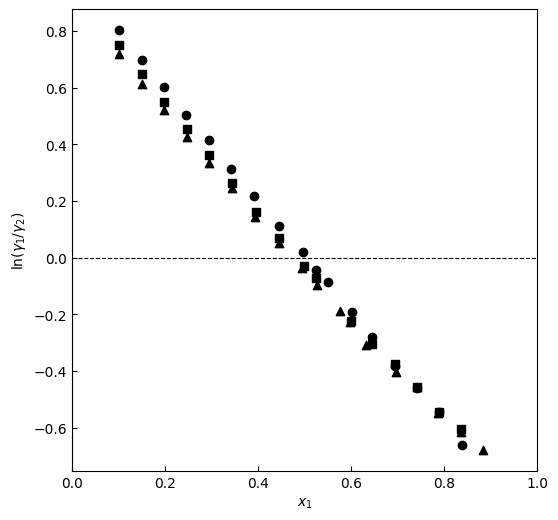

In [30]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], np.log(solHayden50[0]/solHayden50[1]), color='black')
plt.scatter(Xexp75[0], np.log(solHayden75[0]/solHayden75[1]), marker='s', color='black')
plt.scatter(Xexp94[0], np.log(solHayden94[0]/solHayden94[1]), marker='^', color='black')
plt.plot(x1, np.log(gam1leg50/gam2leg50), linestyle='solid', linewidth=0.8, color='blue')
plt.plot(x1, np.log(gam1leg75/gam2leg75), linestyle='solid', linewidth=0.8, color='red')
plt.plot(x1, np.log(gam1leg94/gam2leg94), linestyle='solid', linewidth=0.8, color='ForestGreen')
plt.axhline(y=0, linestyle='dashed', linewidth=0.8, color='black')
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylabel('$\mathrm{ln}(\gamma_{1}/\gamma_{2})$')
plt.savefig('Poster_VLE.svg', format='svg', dpi=1200, transparent=True)

In [31]:
fig.savefig("dbe-nbOH_ratio_Fredenslund.pdf", bbox_inches='tight')

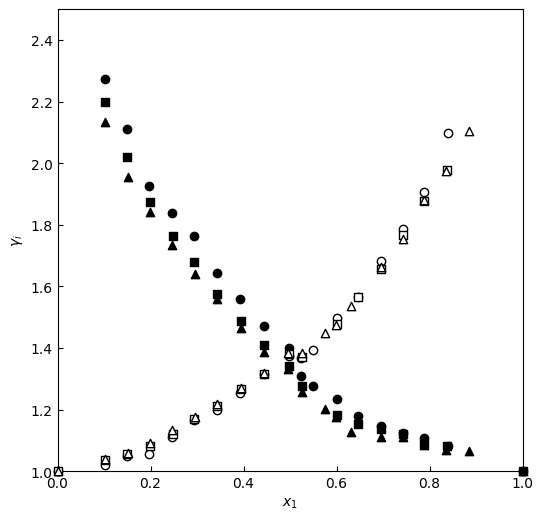

In [32]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], solHayden50[0], c='black', clip_on=False, zorder=10)
plt.scatter(Xexp50[0], solHayden50[1], c='white', edgecolors='black', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], solHayden75[0], marker='s', c='black', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], solHayden75[1], marker='s', c='white', edgecolors='black', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], solHayden94[0], marker='^', c='black', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], solHayden94[1], marker='^', c='white', edgecolors='black', clip_on=False, zorder=10)
plt.plot(x1, gam1leg50, x1, gam2leg50, linestyle='solid', color='blue')
plt.plot(x1, gam1leg75, x1, gam2leg75, linestyle='solid', color='red')
plt.plot(x1, gam1leg94, x1, gam2leg94, linestyle='solid', color='ForestGreen')
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylim([1, 2.5])
plt.ylabel('$\gamma_{i}$')
plt.show()

In [37]:
fig.savefig("dbe-nbOH_gamorig.pdf", bbox_inches='tight')

NameError: name 'errorgam150' is not defined

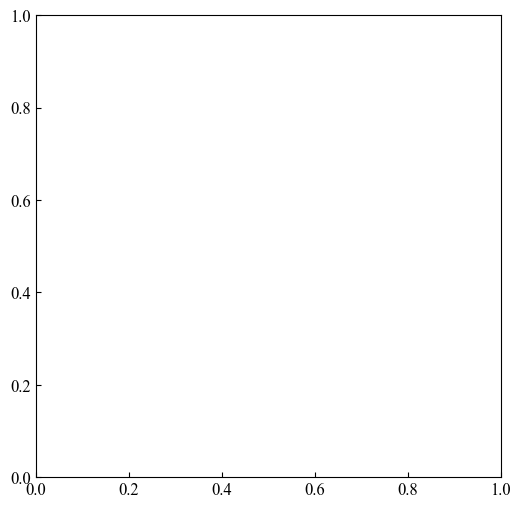

In [33]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], errorgam150, color='blue', clip_on=False, zorder=10)
plt.scatter(Xexp50[0], errorgam250, c='white', edgecolors='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], errorgam175, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], errorgam275, marker='s', c='white', edgecolors='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], errorgam194, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], errorgam294, marker='^', c='white', edgecolors='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta \gamma$')
plt.show()

In [39]:
fig.savefig("dbe-nbOH_resgam.pdf", bbox_inches='tight')

In [34]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], bdpleg50, color='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], bdpleg75, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], bdpleg94, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta p$/kPa')
plt.show()

NameError: name 'bdpleg50' is not defined

<Figure size 600x600 with 0 Axes>

In [55]:
fig.savefig("dbe-nbOH_resp.pdf", bbox_inches='tight')

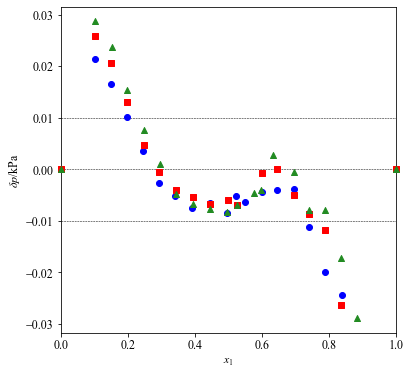

In [56]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], bdy1leg50, color='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], bdy1leg75, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], bdy1leg94, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta p$/kPa')
plt.show()

In [57]:
fig.savefig("dbe-nbOH_resy1.pdf", bbox_inches='tight')

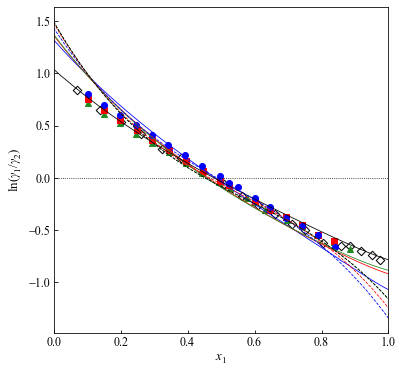

In [98]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp101[0], np.log(solHayden101[0]/solHayden101[1]), marker='D', c='white', edgecolors='black')
plt.scatter(Xexp94[0], np.log(solHayden94[0]/solHayden94[1]), marker='^', color='ForestGreen')
plt.scatter(Xexp75[0], np.log(solHayden75[0]/solHayden75[1]), marker='s', color='red')
plt.scatter(Xexp50[0], np.log(solHayden50[0]/solHayden50[1]), color='blue')
plt.plot(x1, np.log(gam1leg50/gam2leg50), linestyle='dashed', linewidth=0.8, color='blue', label='_nolegend_')
plt.plot(x1, np.log(gam1leg75/gam2leg75), linestyle='dashed', linewidth=0.8, color='red', label='_nolegend_')
plt.plot(x1, np.log(gam1leg94/gam2leg94), linestyle='dashed', linewidth=0.8, color='ForestGreen', label='_nolegend_')
plt.plot(x1, np.log(gam1leg101/gam2leg101), linestyle='dashed', linewidth=0.8, color='black', label='_nolegend_')
plt.axhline(y=0, linestyle='dotted', linewidth=0.8, color='black')
plt.xlim([0, 1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('$x_{1}$', fontsize=13)
plt.ylabel('$\mathrm{ln}(\gamma_{1}/\gamma_{2})$', fontsize=13)
plt.show()

In [99]:
fig.savefig("dbe-nbOH_ratio.pdf", bbox_inches='tight')

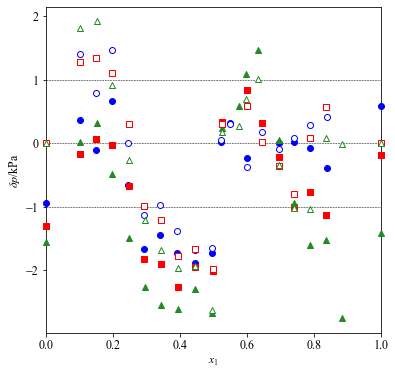

In [116]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], bdpleg50, c='white', edgecolors='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], bdpleg75, c='white', edgecolors='red', marker='s', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], bdpleg94, c='white', edgecolors='ForestGreen', marker='^', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-1.0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=1.0, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta p$/kPa')
plt.show()

In [117]:
fig.savefig("dbe-nbOH_respleg.pdf", bbox_inches='tight')

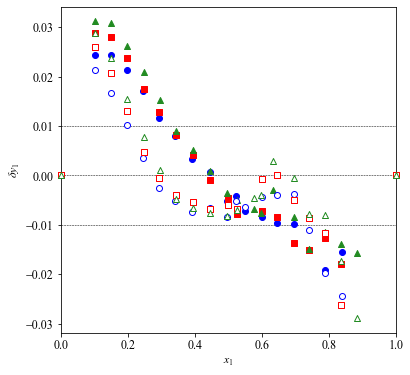

In [110]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], bdy1leg50, c='white', edgecolors='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], bdy1leg75, c='white', edgecolors='red', marker='s', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], bdy1leg94, c='white', edgecolors='ForestGreen', marker='^', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta y_{1}$')
plt.show()

In [111]:
fig.savefig("dbe-nbOH_resy1leg.pdf", bbox_inches='tight')

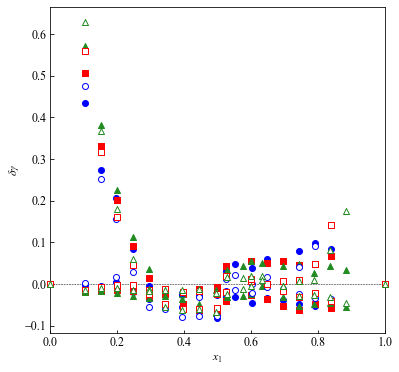

In [112]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], errorgam150, c='white', edgecolors='blue', clip_on=False, zorder=10)
plt.scatter(Xexp50[0], errorgam250, c='white', edgecolors='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], errorgam175, marker='s', c='white', edgecolors='red', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], errorgam275, marker='s', c='white', edgecolors='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], errorgam194, marker='^', c='white', edgecolors='ForestGreen', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], errorgam294, marker='^', c='white', edgecolors='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta \gamma$')
plt.show()

In [113]:
fig.savefig("dbe-nbOH_resgamLeg.pdf", bbox_inches='tight')

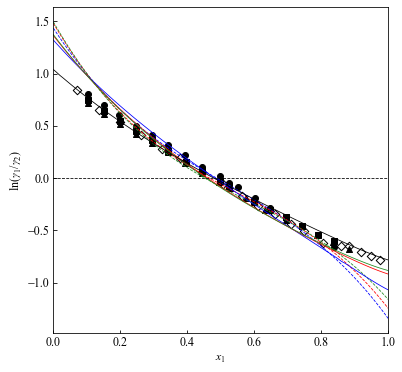

In [118]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], np.log(solHayden50[0]/solHayden50[1]), color='black')
plt.scatter(Xexp75[0], np.log(solHayden75[0]/solHayden75[1]), marker='s', color='black')
plt.scatter(Xexp94[0], np.log(solHayden94[0]/solHayden94[1]), marker='^', color='black')
plt.plot(x1, np.log(gam1leg50/gam2leg50), linestyle='dashed', linewidth=0.8, color='blue')
plt.plot(x1, np.log(gam1leg75/gam2leg75), linestyle='dashed', linewidth=0.8, color='red')
plt.plot(x1, np.log(gam1leg94/gam2leg94), linestyle='dashed', linewidth=0.8, color='ForestGreen')
plt.axhline(y=0, linestyle='dashed', linewidth=0.8, color='black')
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylabel('$\mathrm{ln}(\gamma_{1}/\gamma_{2})$')
plt.show()

In [119]:
fig.savefig("global_dbe-nbOH_ratio.pdf", bbox_inches='tight')

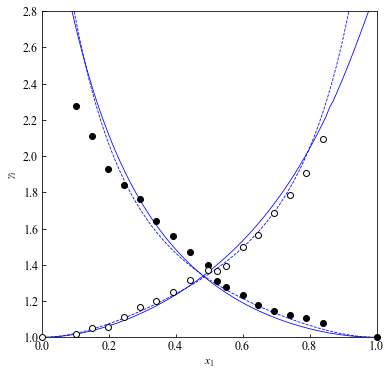

In [120]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], solHayden50[0], c='black', clip_on=False, zorder=10)
plt.scatter(Xexp50[0], solHayden50[1], c='white', edgecolors='black', clip_on=False, zorder=10)
plt.plot(x1, gam1leg50, x1, gam2leg50, linestyle='dashed', color='blue', linewidth=0.8)
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylim([1, 2.8])
plt.ylabel('$\gamma_{i}$')
plt.show()

In [121]:
fig.savefig("dbe-nbOH_gam50orig.pdf", bbox_inches='tight')

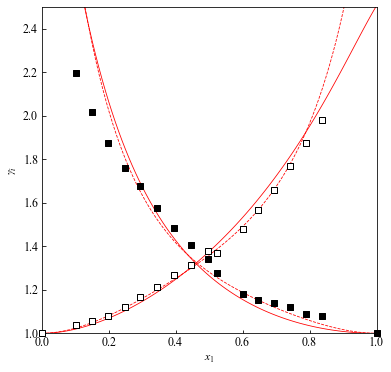

In [122]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp75[0], solHayden75[0], marker='s', c='black', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], solHayden75[1], marker='s', c='white', edgecolors='black', clip_on=False, zorder=10)
plt.plot(x1, gam1leg75, x1, gam2leg75, linestyle='dashed', color='red', linewidth=0.8)
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylim([1, 2.5])
plt.ylabel('$\gamma_{i}$')
plt.show()

In [123]:
fig.savefig("dbe-nbOH_gam75orig.pdf", bbox_inches='tight')

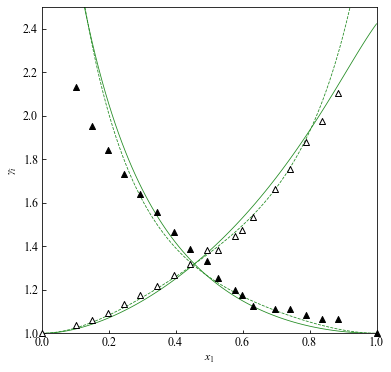

In [124]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp94[0], solHayden94[0], marker='^', c='black', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], solHayden94[1], marker='^', c='white', edgecolors='black', clip_on=False, zorder=10)
plt.plot(x1, gam1leg94, x1, gam2leg94, linestyle='dashed', color='ForestGreen', linewidth=0.8)
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylim([1, 2.5])
plt.ylabel('$\gamma_{i}$')
plt.show()

In [125]:
fig.savefig("dbe-nbOH_gam94orig.pdf", bbox_inches='tight')

In [128]:
dfgamphi50 = pd.DataFrame(np.hstack((np.vstack(Texp50), np.vstack(Xexp50[0]), np.vstack(Yexp50[0]), np.vstack(np.round(solHayden50[0],3)), np.vstack(np.round(solHayden50[1],3)), np.vstack(np.round(solHayden50[2],3)))),
                   columns = ['T', 'x1', 'y1', 'gam1', 'gam2', 'gE'])
dfgamphi75 = pd.DataFrame(np.hstack((np.vstack(Texp75), np.vstack(Xexp75[0]), np.vstack(Yexp75[0]), np.vstack(np.round(solHayden75[0],3)), np.vstack(np.round(solHayden75[1],3)), np.vstack(np.round(solHayden75[2],3)))),
                   columns = ['T', 'x1', 'y1', 'gam1', 'gam2', 'gE'])
dfgamphi94 = pd.DataFrame(np.hstack((np.vstack(Texp94), np.vstack(Xexp94[0]), np.vstack(Yexp94[0]), np.vstack(np.round(solHayden94[0],3)), np.vstack(np.round(solHayden94[1],3)), np.vstack(np.round(solHayden94[2],3)))),
                   columns = ['T', 'x1', 'y1', 'gam1', 'gam2', 'gE'])

In [129]:
with pd.ExcelWriter('dbe-nbOH_VLE_results.xlsx') as writer:
    dfgamphi50.to_excel(writer, sheet_name = 'gamphi50')
    dfgamphi75.to_excel(writer, sheet_name = 'gamphi75')
    dfgamphi94.to_excel(writer, sheet_name = 'gamphi94')